In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [4]:
data=pd.read_csv("weather_dt.csv")
data

,DAY,Weather,Temp,Humidity,Wind,Status
0,Day 1,Sunny,Hot,High,Weak,NO
1,Day 2,Sunny,Hot,High,Strong,NO
2,Day 3,Overcast,Hot,High,Weak,YES
3,Day 4,Rain,Mild,High,Weak,YES
4,Day 5,Rain,Cool,Normal,Weak,YES
5,Day 6,Rain,Cool,Normal,Strong,NO
6,Day 7,Overcast,Cool,Normal,Strong,YES
7,Day 8,Sunny,Mild,High,Weak,NO
8,Day 9,Sunny,Cool,Normal,Weak,YES
9,Day 10,Rain,Mild,Normal,Weak,YES


# Encode Categorical Data

In [5]:
le_weather = LabelEncoder()
le_temp = LabelEncoder()
le_humidity = LabelEncoder()
le_wind = LabelEncoder()
le_status = LabelEncoder()
data['Weather'] = le_weather.fit_transform(data['Weather'])
data['Temp'] = le_temp.fit_transform(data['Temp'])
data['Humidity'] = le_humidity.fit_transform(data['Humidity'])
data['Wind'] = le_wind.fit_transform(data['Wind'])
data['Status'] = le_status.fit_transform(data['Status'])

data

,DAY,Weather,Temp,Humidity,Wind,Status
0,Day 1,2,1,0,1,0
1,Day 2,2,1,0,0,0
2,Day 3,0,1,0,1,1
3,Day 4,1,2,0,1,1
4,Day 5,1,0,1,1,1
5,Day 6,1,0,1,0,0
6,Day 7,0,0,1,0,1
7,Day 8,2,2,0,1,0
8,Day 9,2,0,1,1,1
9,Day 10,1,2,1,1,1


# Feature	Example Encoding
## Weather: 	Overcast=0, Rain=1, Sunny=2
## Temp:    	Cool=0, Hot=1, Mild=2
## Humidity: 	High=0, Normal=1
## Wind:    	Strong=0, Weak=1
## Status:  	No=0, Yes=1

# Separate Features and Target

In [6]:
X = data.drop(['DAY','Status'], axis=1)
Y = data['Status']
print(X)
print(Y)

    Weather  Temp  Humidity  Wind
0         2     1         0     1
1         2     1         0     0
2         0     1         0     1
3         1     2         0     1
4         1     0         1     1
5         1     0         1     0
6         0     0         1     0
7         2     2         0     1
8         2     0         1     1
9         1     2         1     1
10        2     2         1     0
11        0     2         0     0
12        0     1         1     1
13        1     2         0     0
0     0
1     0
2     1
3     1
4     1
5     0
6     1
7     0
8     1
9     1
10    1
11    1
12    1
13    0
Name: Status, dtype: int32


# Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.3, random_state=42
)

print(X_test)

    Weather  Temp  Humidity  Wind
9         1     2         1     1
11        0     2         0     0
0         2     1         0     1
12        0     1         1     1
5         1     0         1     0


# Build Decision Tree Using Entropy

In [11]:
model = DecisionTreeClassifier(criterion='entropy')  # criterion='entropy'uses FOR  Information Gain.
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

# Prediction

In [12]:
y_pred = model.predict(X_test)

print("Predicted Results Are: ",y_pred)

Predicted Results Are:  [1 0 0 1 1]


# Accuracy

In [13]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy =", accuracy)

Accuracy = 0.6


# Confusion Matrix

In [14]:

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1 1]
 [1 2]]


# Classification Report

In [15]:
CR=classification_report(y_test, y_pred)
print(CR)

              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.67      0.67      0.67         3

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5



# Visualize the Decision Tree

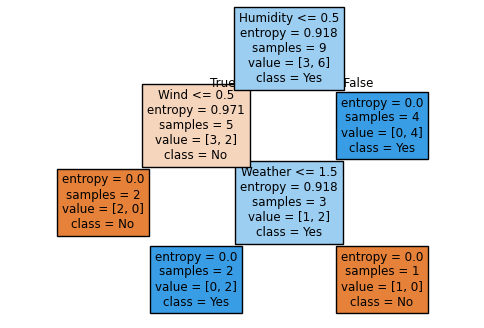

In [16]:
plt.figure(figsize=(6,4))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No','Yes'],
    filled=True
)

plt.show()

                    Weather
                /      |      \
         Overcast    Sunny     Rain
            |           |         |
           Yes      Humidity     Wind
                     /   \       /  \
                  High Normal Weak Strong
                    |      |    |      |
                   No     Yes  Yes     No

# Q Find for single user means how enter input by the user

In [23]:
new_data = [[1,1,1,0]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("All are Good you can go for play")
else:
    print("Sorry Weather is not GOOD")

All are Good you can go for play


C:\Users\HP INDIA\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
